# Heat Exchanger Model Demonstration
This notebook demonstrates the physical heat exchanger model, its failure modes, and how varying degradation parameters affects observable sensor signals.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..") / "src"))

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from numpyro.infer import Predictive
from numpyro import handlers

import hx_models.heat_exchanger as hx
from hx_models.style import (
    apply_paper_style, OBS_LABELS, TRUE_COLOR, SCENARIO_COLORS,
    FOULING_COLOR, LEAK_COLOR,
)

apply_paper_style()

## 1. Clean Heat Exchanger Baseline

The heat exchanger is modeled using the **NTU-effectiveness method** for counterflow geometry. With fixed inlet temperatures ($T_{h,\mathrm{in}}$, $T_{c,\mathrm{in}}$), mass flow rates, and heat capacities, the outlet temperatures depend on the overall thermal conductance $UA$. Higher $UA$ improves heat transfer: $T_{h,\mathrm{out}}$ decreases and $T_{c,\mathrm{out}}$ increases toward their limiting values.

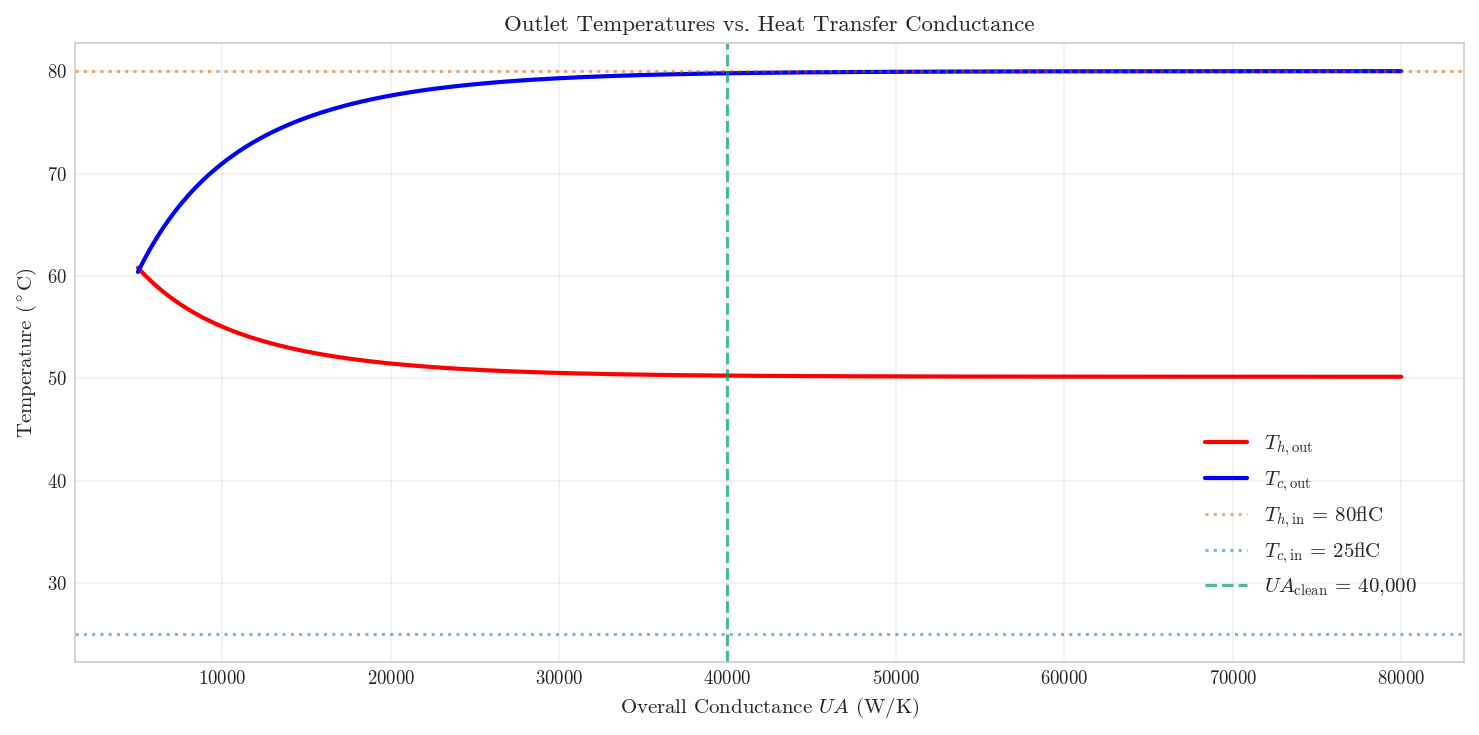

In [2]:
UA_values = np.linspace(5000, 80000, 200)
Th_in, Tc_in = 80.0, 25.0
m_hot, m_cold = 2.0, 2.0
cp_hot, cp_cold = 3500.0, 1900.0

Th_out = []
Tc_out = []
for UA in UA_values:
    th, tc = hx.deterministic_outlet_temps(Th_in, Tc_in, m_hot, m_cold, cp_hot, cp_cold, UA)
    Th_out.append(float(th))
    Tc_out.append(float(tc))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(UA_values, Th_out, 'r-', lw=2, label=r'$T_{h,\mathrm{out}}$')
ax.plot(UA_values, Tc_out, 'b-', lw=2, label=r'$T_{c,\mathrm{out}}$')
ax.axhline(Th_in, color=TRUE_COLOR, ls=':', alpha=0.5, label=r'$T_{h,\mathrm{in}}$ = 80°C')
ax.axhline(Tc_in, color=FOULING_COLOR, ls=':', alpha=0.5, label=r'$T_{c,\mathrm{in}}$ = 25°C')
ax.axvline(40000, color=SCENARIO_COLORS[2], ls='--', alpha=0.7, label=r'$UA_{\mathrm{clean}}$ = 40,000')
ax.set_xlabel(r'Overall Conductance $UA$ (W/K)')
ax.set_ylabel(r'Temperature ($^\circ$C)')
ax.set_title('Outlet Temperatures vs. Heat Transfer Conductance')
ax.legend(loc='upper left', bbox_to_anchor=(0.80, 0.40), fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Fouling Dynamics

Fouling is modeled as a **compound Poisson process** $R(t)$: resistance accumulates via random jumps with mean size $\beta_f$, driven by a Poisson process with rate $\lambda$. After a changepoint $\tau$, degradation activates and $R(t)$ grows stochastically. Stronger fouling ($\beta_f$ larger) yields faster accumulation; higher $\lambda$ gives more frequent jumps.

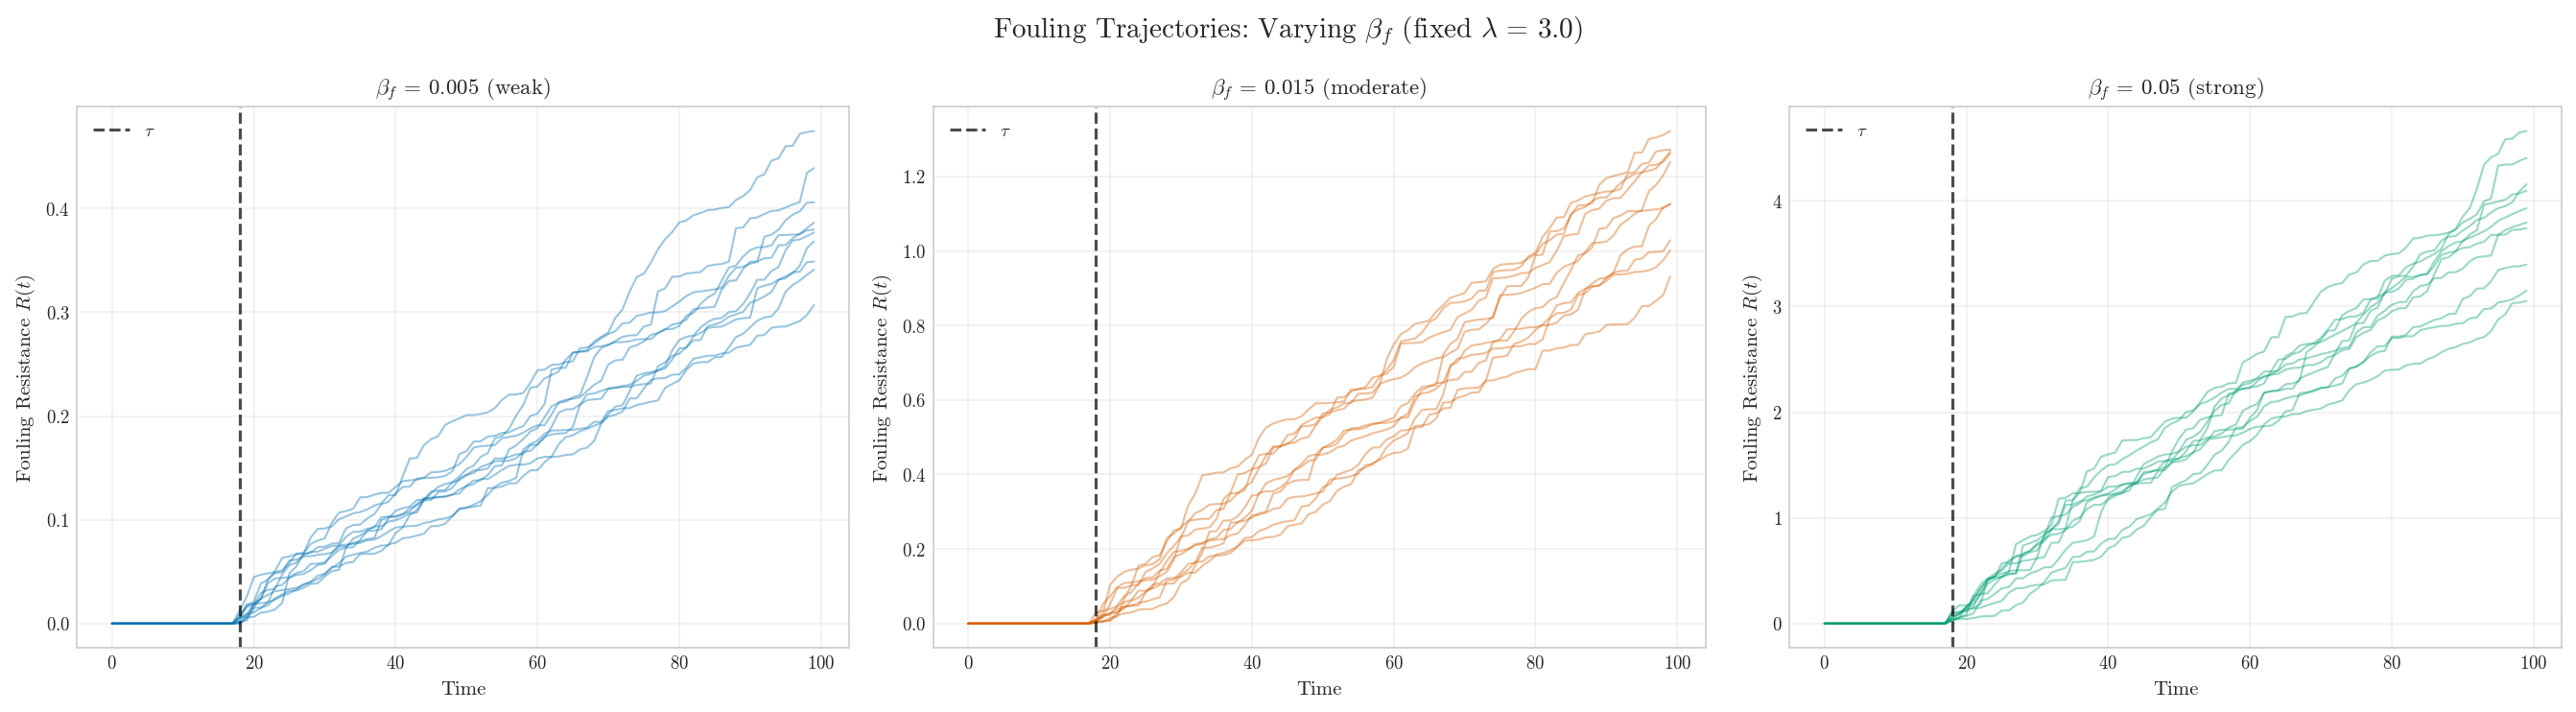

In [3]:
T = 100
tau = 18.0
tau01 = (tau - 1.0) / (T - 2.0)
n_realizations = 10

beta_f_values = [0.005, 0.015, 0.05]
beta_f_labels = [r'$\beta_f$ = 0.005 (weak)', r'$\beta_f$ = 0.015 (moderate)', r'$\beta_f$ = 0.05 (strong)']
colors = SCENARIO_COLORS[:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for col, (bf, label, color) in enumerate(zip(beta_f_values, beta_f_labels, colors)):
    ax = axes[col]
    for r in range(n_realizations):
        rng_key = jax.random.PRNGKey(r * 100 + col)
        condition_data = {
            "tau01": tau01,
            "p": jnp.array([0.0, 1.0, 0.0]),
            "beta_f": bf,
            "beta_l": 0.0004,
            "lambda_rate": 3.0,
        }
        model = handlers.condition(hx.HX_with_failure_loop, data=condition_data)
        predictive = Predictive(model, num_samples=1)
        sim = predictive(rng_key, T=T, hard_step=True)
        fouling = np.asarray(sim["fouling_F_t"]).squeeze()
        ax.plot(np.arange(T), fouling, color=color, alpha=0.4, lw=1)
    
    ax.axvline(tau, color='black', ls='--', alpha=0.7, label=r'$\tau$')
    ax.set_xlabel('Time')
    ax.set_ylabel(r'Fouling Resistance $R(t)$')
    ax.set_title(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle(r'Fouling Trajectories: Varying $\beta_f$ (fixed $\lambda$ = 3.0)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

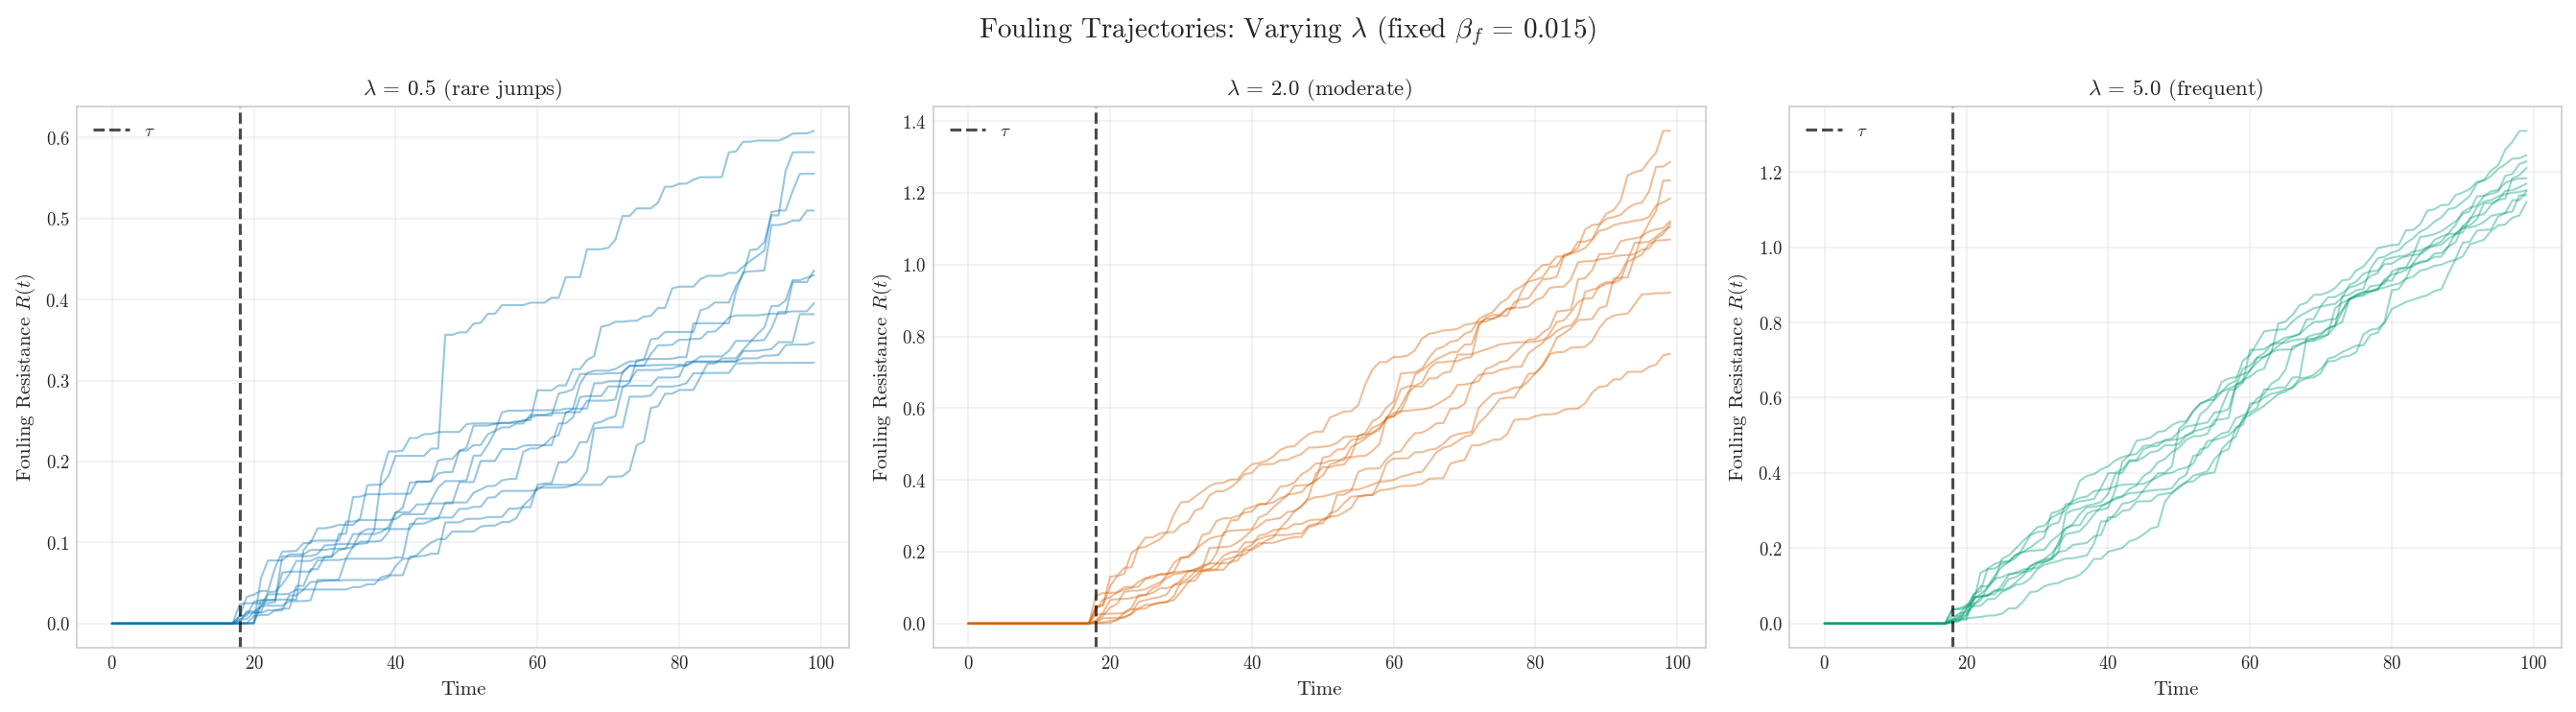

In [4]:
lambda_values = [0.5, 2.0, 5.0]
lambda_labels = [r'$\lambda$ = 0.5 (rare jumps)', r'$\lambda$ = 2.0 (moderate)', r'$\lambda$ = 5.0 (frequent)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for col, (lam, label, color) in enumerate(zip(lambda_values, lambda_labels, colors)):
    ax = axes[col]
    for r in range(n_realizations):
        rng_key = jax.random.PRNGKey(r * 100 + col + 50)
        condition_data = {
            "tau01": tau01,
            "p": jnp.array([0.0, 1.0, 0.0]),
            "beta_f": 0.015,
            "beta_l": 0.0004,
            "lambda_rate": lam,
        }
        model = handlers.condition(hx.HX_with_failure_loop, data=condition_data)
        predictive = Predictive(model, num_samples=1)
        sim = predictive(rng_key, T=T, hard_step=True)
        fouling = np.asarray(sim["fouling_F_t"]).squeeze()
        ax.plot(np.arange(T), fouling, color=color, alpha=0.4, lw=1)
    
    ax.axvline(tau, color='black', ls='--', alpha=0.7, label=r'$\tau$')
    ax.set_xlabel('Time')
    ax.set_ylabel(r'Fouling Resistance $R(t)$')
    ax.set_title(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle(r'Fouling Trajectories: Varying $\lambda$ (fixed $\beta_f$ = 0.015)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Leakage Dynamics

Internal leakage is modeled by $L(t)$, the fraction of hot-side mass flow lost to leakage after changepoint $\tau$. The growth rate is controlled by $\beta_l$: larger $\beta_l$ leads to faster increase in $L(t)$ and thus greater reduction in $\dot{m}_{\mathrm{hot,out}}$.

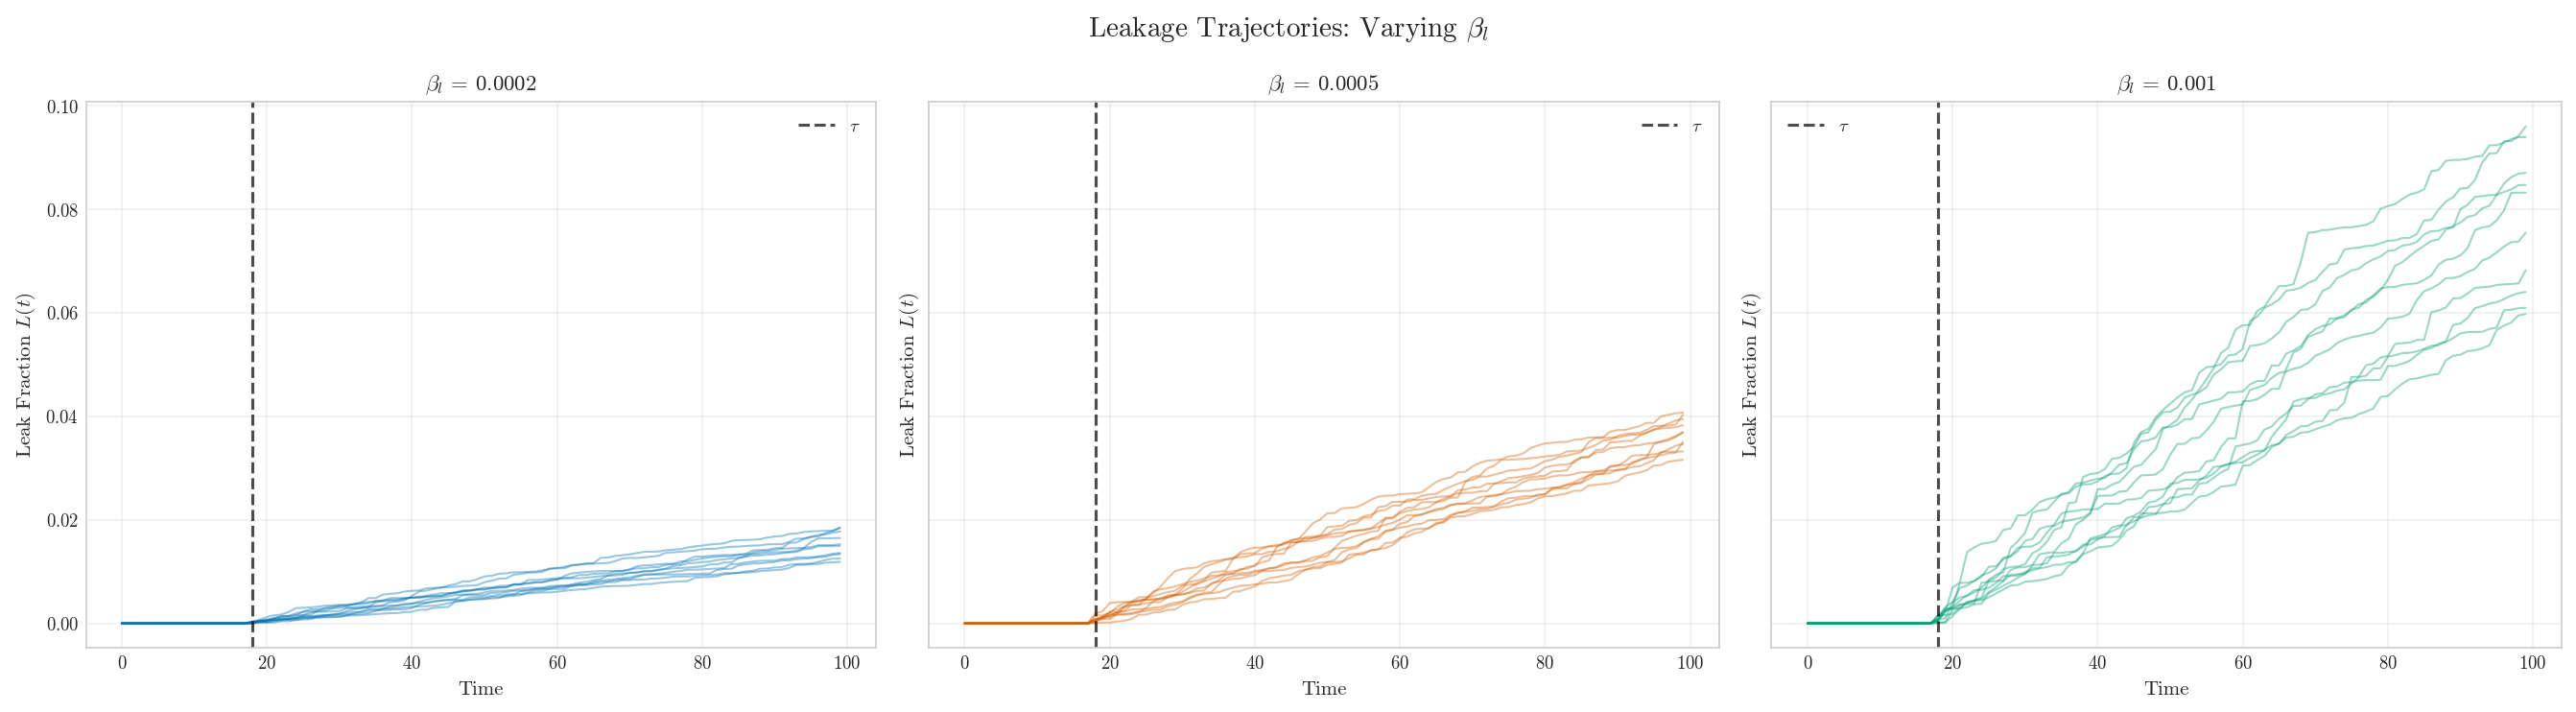

In [5]:
beta_l_values = [0.0002, 0.0005, 0.001]
beta_l_labels = [r'$\beta_l$ = 0.0002', r'$\beta_l$ = 0.0005', r'$\beta_l$ = 0.001']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for col, (bl, label, color) in enumerate(zip(beta_l_values, beta_l_labels, colors)):
    ax = axes[col]
    for r in range(n_realizations):
        rng_key = jax.random.PRNGKey(r * 100 + col + 200)
        condition_data = {
            "tau01": tau01,
            "p": jnp.array([0.0, 0.0, 1.0]),
            "beta_f": 0.015,
            "beta_l": bl,
            "lambda_rate": 2.0,
        }
        model = handlers.condition(hx.HX_with_failure_loop, data=condition_data)
        predictive = Predictive(model, num_samples=1)
        sim = predictive(rng_key, T=T, hard_step=True)
        leak = np.asarray(sim["leak_frac_t"]).squeeze()
        ax.plot(np.arange(T), leak, color=color, alpha=0.4, lw=1)
    
    ax.axvline(tau, color='black', ls='--', alpha=0.7, label=r'$\tau$')
    ax.set_xlabel('Time')
    ax.set_ylabel(r'Leak Fraction $L(t)$')
    ax.set_title(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle(r'Leakage Trajectories: Varying $\beta_l$', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Failure Mode Sensor Signatures

Different failure modes produce distinguishable patterns in observable sensors. Fouling increases thermal resistance $R(t)$, reducing effective $UA$ and raising $T_{h,\mathrm{out}}$ while lowering $T_{c,\mathrm{out}}$. Leakage reduces $\dot{m}_{\mathrm{hot,out}}$ directly. No-failure maintains baseline behavior. The plots below show true (latent) vs observed (noisy) signals for each mode.

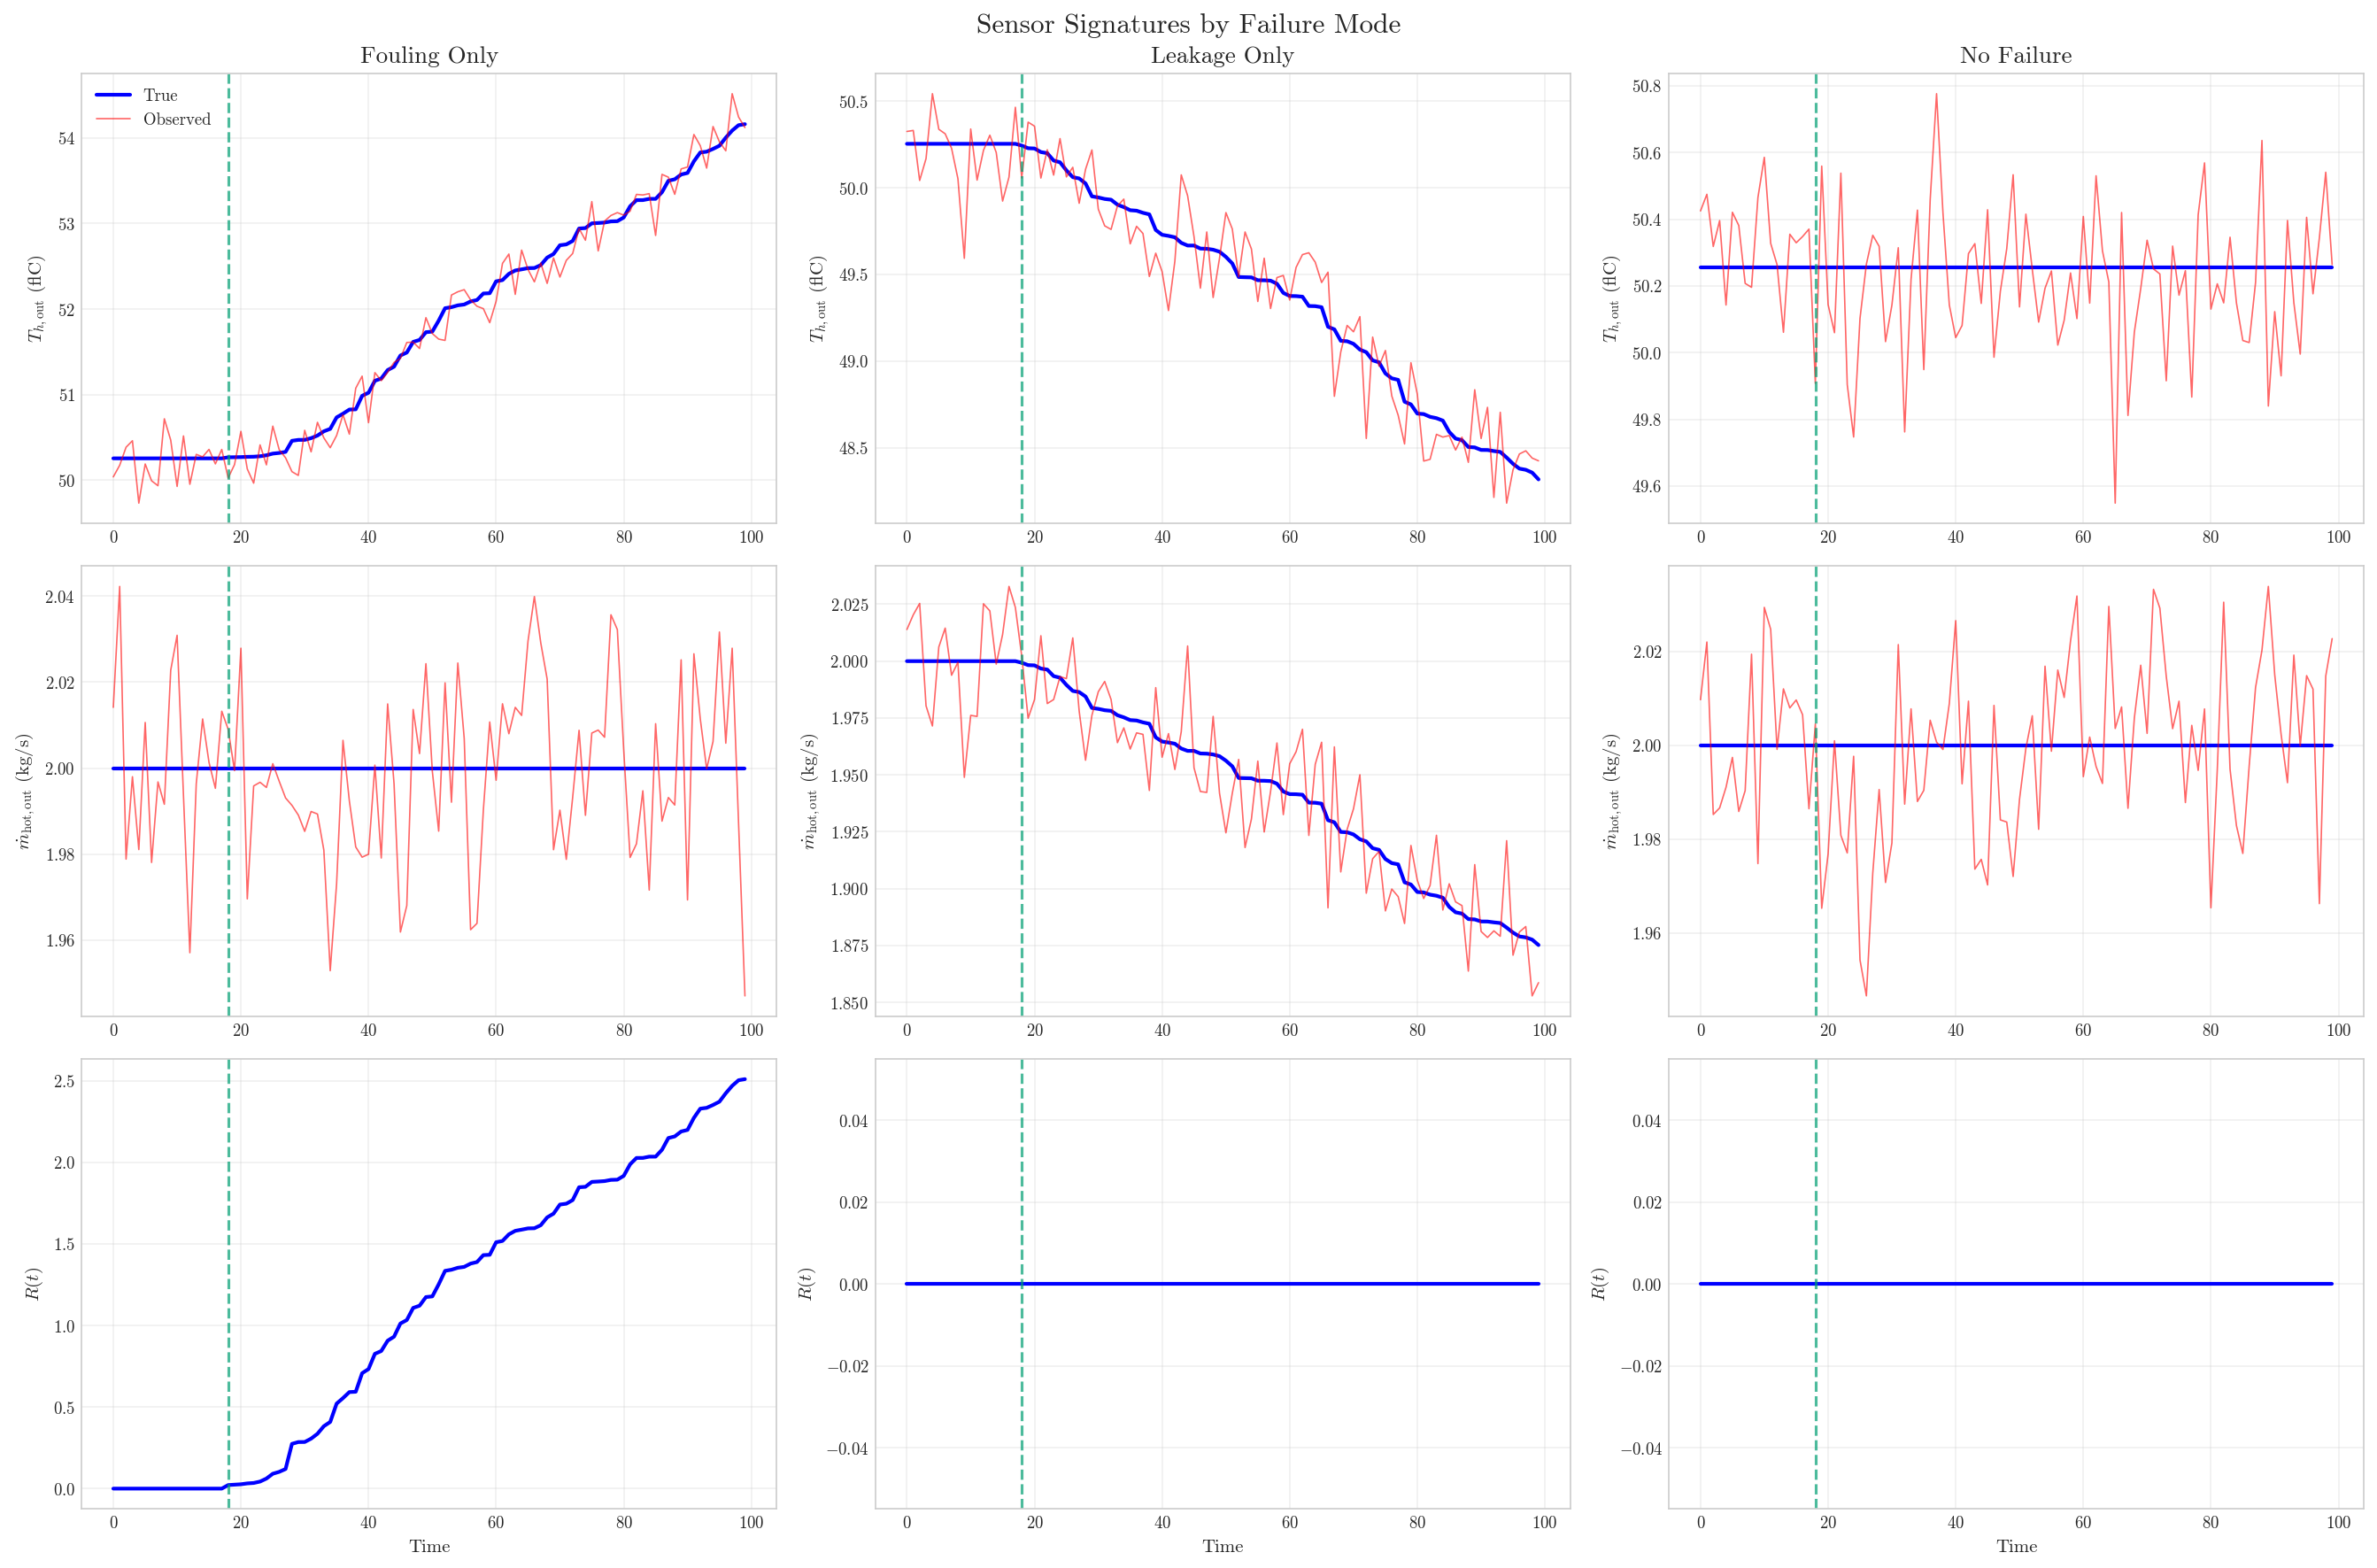

In [6]:
modes = [
    ("Fouling Only", {"p": jnp.array([0.0, 1.0, 0.0]), "beta_f": 0.03, "beta_l": 0.0004, "lambda_rate": 3.0}),
    ("Leakage Only", {"p": jnp.array([0.0, 0.0, 1.0]), "beta_f": 0.015, "beta_l": 0.0008, "lambda_rate": 2.0}),
    ("No Failure",   {"p": jnp.array([1.0, 0.0, 0.0]), "beta_f": 0.015, "beta_l": 0.0004, "lambda_rate": 2.0}),
]

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
obs_keys = [
    ("Th_out", "Th_out_obs", r"$T_{h,\mathrm{out}}$ (°C)"),
    ("m_hot_out", "m_hot_out_obs", r"$\dot{m}_{\mathrm{hot,out}}$ (kg/s)"),
    ("fouling_F", None, r"$R(t)$"),
]

for col, (mode_name, params) in enumerate(modes):
    rng_key = jax.random.PRNGKey(42 + col)
    condition_data = {"tau01": tau01, **params}
    model = handlers.condition(hx.HX_with_failure_loop, data=condition_data)
    predictive = Predictive(model, num_samples=1)
    sim = predictive(rng_key, T=T, hard_step=True)
    t = np.arange(T)
    
    sq = lambda x: np.asarray(x).squeeze()
    
    m_hot_in_val = float(sq(sim["m_hot_in_true"]))
    UA_t = sq(sim["UA_t"])
    m_hot_out_t = sq(sim["m_hot_out_t"])
    Th_out_true, Tc_out_true = hx.deterministic_outlet_temps(
        80.0, 25.0, m_hot_out_t, 2.0, 3500.0, 1900.0, UA_t)
    
    data_map = {
        "Th_out": (np.asarray(Th_out_true), sq(sim["Th_out_obs"])),
        "m_hot_out": (np.asarray(m_hot_out_t), sq(sim["m_hot_out_obs"])),
        "fouling_F": (sq(sim["fouling_F_t"]), None),
    }
    
    for row, (key, obs_key, ylabel) in enumerate(obs_keys):
        ax = axes[row, col]
        true_vals, obs_vals = data_map[key]
        ax.plot(t, true_vals, 'b-', lw=2, label='True')
        if obs_vals is not None:
            ax.plot(t, obs_vals, 'r-', lw=0.8, alpha=0.6, label='Observed')
        ax.axvline(tau, color=SCENARIO_COLORS[2], ls='--', alpha=0.7)
        ax.set_ylabel(ylabel)
        if row == 0:
            ax.set_title(mode_name, fontsize=13, fontweight='bold')
        if row == 2:
            ax.set_xlabel('Time')
        ax.grid(True, alpha=0.3)
        if row == 0 and col == 0:
            ax.legend(fontsize=9)

fig.suptitle('Sensor Signatures by Failure Mode', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Temporal Activation $S(i)$

The changepoint $\tau$ governs when degradation activates. In principle this is a hard step where degradation is absent before $\tau$ and present after. However, a hard step is **not differentiable** at $\tau$, which is problematic because gradient-based inference methods (e.g. the NUTS sampler used in our MCMC) require smooth gradients with respect to all latent parameters, including $\tau$.

To address this, the model replaces the hard step with a **sigmoid approximation**:

$$S(i) = \frac{1}{1 + e^{-k(i - \tau)}}$$

The sharpness parameter $k$ controls how closely the sigmoid resembles a true step function. Larger $k$ gives a sharper transition ($k \to \infty$ recovers the hard step), while smaller $k$ produces a smoother blend. The plot below zooms in around $\tau$ to illustrate this trade-off. For data generation we use a hard step (i.e. the true physical process), while for inference we use the smooth sigmoid ($k = 150$) so that gradients flow through $\tau$.

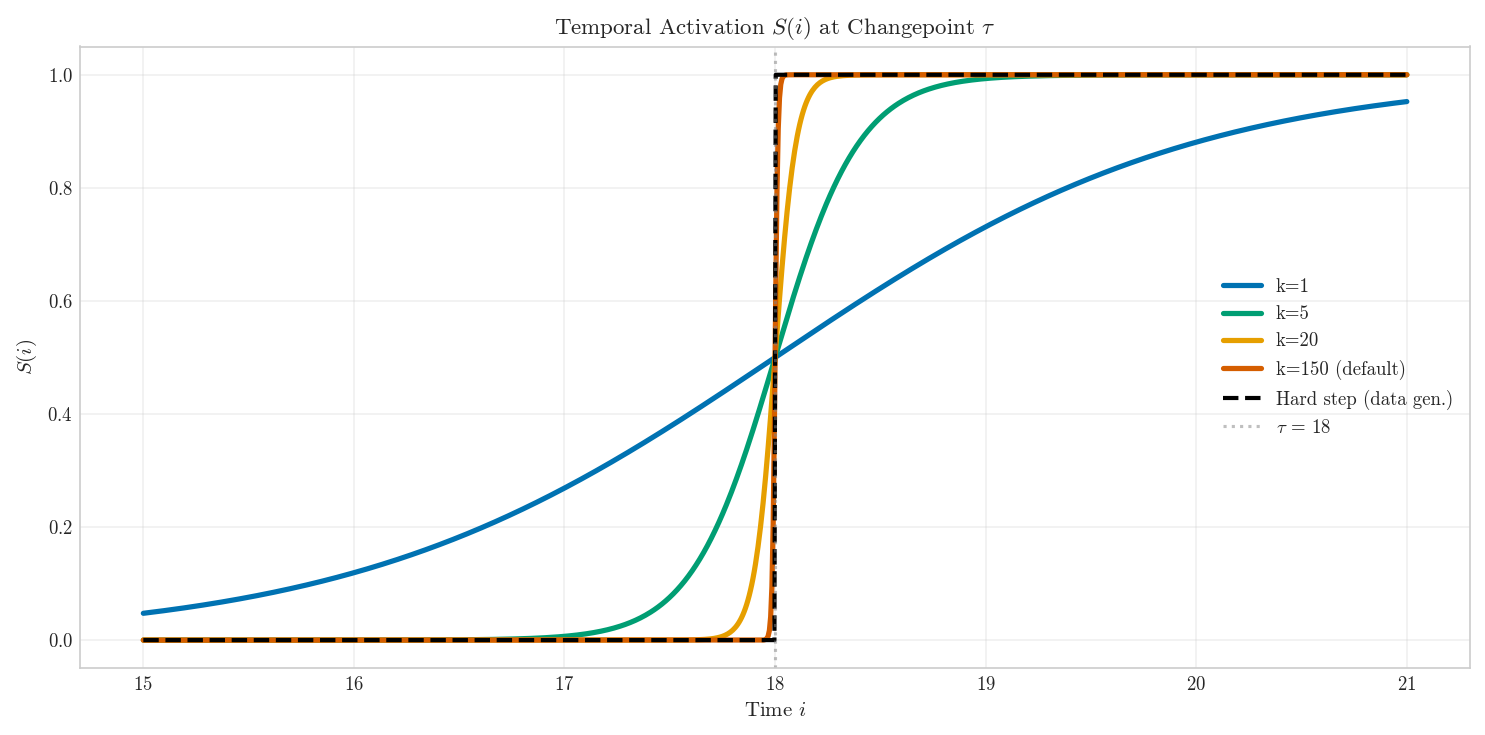

In [8]:
t = np.linspace(15, 21, 1000)
tau_val = 18.0

fig, ax = plt.subplots(figsize=(10, 5))
for k, color, label in [
    (1, SCENARIO_COLORS[0], 'k=1'),
    (5, SCENARIO_COLORS[2], 'k=5'),
    (20, SCENARIO_COLORS[3], 'k=20'),
    (150, SCENARIO_COLORS[1], 'k=150 (default)'),
]:
    s = 1.0 / (1.0 + np.exp(-k * (t - tau_val)))
    ax.plot(t, s, lw=2.5, color=color, label=label)

hard = (t >= tau_val).astype(float)
ax.plot(t, hard, 'k--', lw=2, label='Hard step (data gen.)')
ax.axvline(tau_val, color='gray', ls=':', alpha=0.5, label=rf'$\tau$ = {tau_val:.0f}')
ax.set_xlabel('Time $i$')
ax.set_ylabel(r'$S(i)$')
ax.set_title(r'Temporal Activation $S(i)$ at Changepoint $\tau$')
ax.legend(loc='center right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()